### 1. Importación de Librerías Principales
Carga de TensorFlow, NumPy, librerías de visualización y métricas de evaluación.

In [249]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from keras import layers, models
import numpy as np
import os

### 2. Configuración de Semillas y Reproducibilidad
Importación de módulos aleatorios y configuración para asegurar reproducibilidad en los experimentos.

In [250]:
import random

def set_reproducibility(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Para asegurar operaciones deterministas en la GPU (opcional, puede ser más lento)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)

set_reproducibility(42)

### 3. Definición de Hiperparámetros Base
Establecimiento del número de neuronas base y parámetros iniciales para el modelo de referencia.

In [251]:
n_neurons_base = 339
lr_base = 0.0001
activation_base = 'relu'
dropout_base = 0.1

model = models.Sequential([
        layers.Input(shape=(1280,)),                        # La entrada es un vector de 1280 características
        layers.Dense(n_neurons_base, activation=activation_base),     # Capa oculta con el número de neuronas y función de activación elegidos
        layers.Dropout(dropout_base),                            # Capa de dropout con la tasa elegida
        layers.Dense(4, activation='softmax')               # Capa de salida con 4 neuronas (para 4 clases) y función de activación softmax
    ])

### 4. Configuración de Callbacks
Definición de mecanismos de control como parada temprana (EarlyStopping) y guardado del mejor modelo.

In [252]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

### 5. Compilación del Modelo Base
Configuración del optimizador, función de pérdida y métricas de evaluación.

In [253]:
model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_base),   # Optimizador Adam con la tasa de aprendizaje elegida
        loss='sparse_categorical_crossentropy',                 # Función de pérdida para clasificación multiclase
        metrics=['accuracy']                                    # Métrica de precisión para evaluar el modelo durante el entrenamiento
    )

### 6. Carga de Características Preprocesadas
Lectura de los tensores almacenados (X_train_effnet.npy, etc.) generados en la fase de extracción.

In [254]:
X_train_path = 'X_train_effnet.npy'
y_train_path = 'y_train_effnet.npy'
X_val_path = 'X_val_effnet.npy'
y_val_path = 'y_val_effnet.npy'

X_train = np.load(X_train_path)
y_train = np.load(y_train_path)

X_val = np.load(X_val_path)
y_val = np.load(y_val_path)


X_test, y_test = np.load('X_test_effnet.npy'), np.load('y_test_effnet.npy')

### 7. Entrenamiento del Modelo Base
Ejecución del proceso de entrenamiento (model.fit) sobre las características extraídas.

In [255]:
modelo_entrenado = model.fit(
                        X_train, y_train,
                        epochs=30, # Usa las mismas épocas que en tu entrenamiento final
                        batch_size=64,
                        validation_data=(X_val, y_val),
                        verbose=1,
                        callbacks=callbacks
                        )

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8344 - loss: 0.5948 - val_accuracy: 0.9260 - val_loss: 0.2638
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9471 - loss: 0.2074 - val_accuracy: 0.9461 - val_loss: 0.1709
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9610 - loss: 0.1430 - val_accuracy: 0.9492 - val_loss: 0.1429
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9673 - loss: 0.1158 - val_accuracy: 0.9492 - val_loss: 0.1300
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9686 - loss: 0.1002 - val_accuracy: 0.9461 - val_loss: 0.1233
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9745 - loss: 0.0862 - val_accuracy: 0.9445 - val_loss: 0.1185
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9769 - loss: 0.0779 - val_accuracy: 0.9461 - val_loss: 0.1154
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9772 - loss: 0.0721 - val_accuracy: 0.9492 - val_loss

### 8. Generación de Predicciones
Cálculo de clases predichas sobre el conjunto de prueba utilizando el modelo entrenado.

In [256]:
y_pred = np.argmax(model.predict(X_test), axis=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


### 9. Funciones de Visualización
Definición de funciones auxiliares para graficar el historial de pérdida y precisión del entrenamiento.

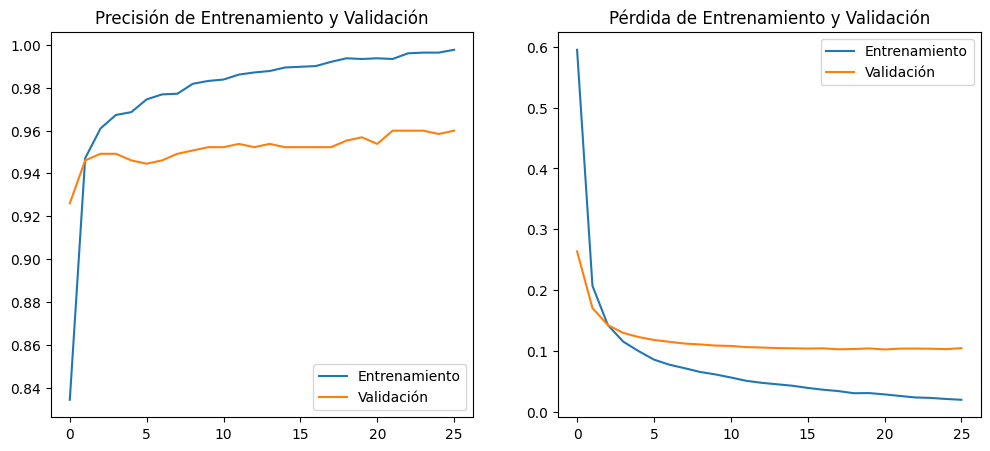

In [257]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Gráfico de Precisión
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Entrenamiento')
    plt.plot(epochs_range, val_acc, label='Validación')
    plt.title('Precisión de Entrenamiento y Validación')
    plt.legend()

    # Gráfico de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Entrenamiento')
    plt.plot(epochs_range, val_loss, label='Validación')
    plt.title('Pérdida de Entrenamiento y Validación')
    plt.legend()
    plt.show()

plot_history(modelo_entrenado)

### 10. Evaluación de Rendimiento y Matriz de Confusión
Cálculo de la precisión final en el conjunto de prueba y generación de la matriz de confusión.

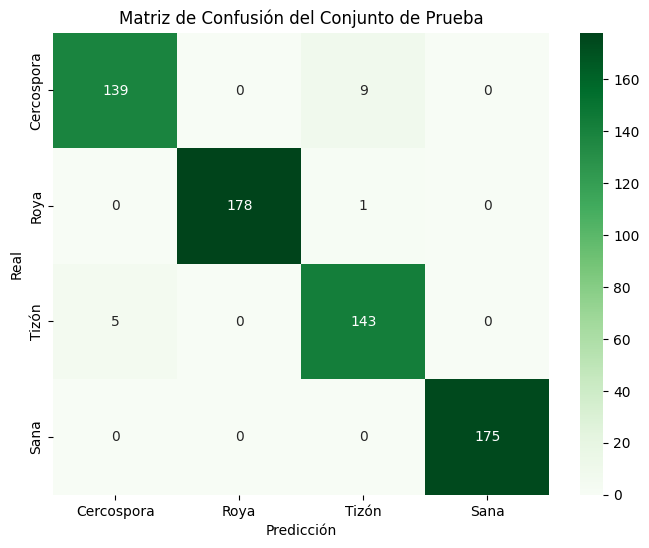

              precision    recall  f1-score   support

  Cercospora       0.97      0.94      0.95       148
        Roya       1.00      0.99      1.00       179
       Tizón       0.93      0.97      0.95       148
        Sana       1.00      1.00      1.00       175

    accuracy                           0.98       650
   macro avg       0.97      0.97      0.97       650
weighted avg       0.98      0.98      0.98       650



In [258]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Cercospora', 'Roya', 'Tizón', 'Sana'],
            yticklabels=['Cercospora', 'Roya', 'Tizón', 'Sana'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión del Conjunto de Prueba')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Cercospora', 'Roya',  'Tizón', 'Sana']))

### 11. Evaluación Final del Modelo
Ejecución de la evaluación formal (model.evaluate) para obtener pérdida y accuracy exactas.

In [259]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Exactitud en conjunto de prueba: {test_acc}")
print(f"Pérdida en conjunto de prueba: {test_loss}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9769 - loss: 0.0709 
Exactitud en conjunto de prueba: 0.9769230484962463
Pérdida en conjunto de prueba: 0.07089927047491074
